# Lecture 13 - Introduction to Machine Learning

## 1. Overview 

**Machine learning** (ML) is a branch of artificial intelligence that involves **training algorithms** to make **predictions** or decisions based on data, **without being explicitly programmed**.

Applications:

- **Finance**: Stock price prediction, fraud detection, risk analysis, customer segmentation, etc.
- **Other fields**: Image recognition, natural language processing, recommendation systems.
    
    
In `Python`, `scikit-learn` is a powerful **library** for machine learning that provides tools for preprocessing data, training models, and evaluating them. 

This notebook covers:
- **Supervised** and **Unsupervised** learning
    - **K-means clustering**
    - **Decision trees**
- **Data** preprocessing
- Using `scikit-learn` :
    - **Importing** ML model class
    - **Instantiating** a model object
    - **Fitting** the model object to data
    - **Predicting** the outcome given the fitted model for some data

In [1]:
import numpy as np 
import pandas as pd
import datetime as dt
from pylab import mpl, plt

plt.style.use('seaborn-v0_8-dark') 
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

np.random.seed(1000)
np.set_printoptions(suppress=True, precision=4)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install scikit-learn

## 2. A primer on Machine Learning

**Machine learning** is a **prediction technology**

2 main steps: 

1. **Training/learning**: Learn patterns from previous outcomes (`data`)
2. **Evaluation/deployment**: Given new inputs, predict most likely outcome

### 2.1 Classes of machine learning models

There 3 broad classes of learning: **supervised**, **unsupervised**, **reinforcement**.

**1. Supervised Learning**  

The model learns from **labeled data** (i.e., input-output pairs). 


<u>Examples</u>

- **Regression**: Predicting a continuous value (e.g., stock prices, real estate values).
- **Classification**: Predicting a categorical label (e.g., credit approval, fraud detection).

**2. Unsupervised Learning** 

The model learns from **unlabeled data** to find hidden patterns or groupings. 

<u>Examples</u>
- **Clustering**: Grouping data points based on similarities (e.g., customer segmentation).
- **Dimensionality reduction**: Reducing the number of features while preserving the most important information (e.g., PCA).

**3. Reinforcement Learning** (`skip`)

The model learns through interactions with an environment and feedback from its actions.

<u>Example</u> 
- Algorithmic trading

### Visual intuition

**Raw data**
<center><img src="Figures/ml-learning-data.jpg" width = 500></center>

**Supervised learning**

Necessary dimension: **Labelled data**
<center><img src="Figures/ml-learning-label.jpg" width = 600></center>

**Supervised learning**

<center><img src="Figures/ml-learning-supervised.jpg" width = 400></center>

**Unsupervised learning**

<center><img src="Figures/ml-learning-unsupervised.jpg" width = 400></center>

**Other example**

<center><img src="Figures/ml-learning-classes-1.jpg" width = 900></center>

### 2.2 Workflow

1. **Problem Definition**
2. **Data**
    - Collection
    - Preparation
        - *missing values, encoding of categorical variables, etc.*
    - Exploration
    - Feature engineering
        - *select and create suitable features for the predictions*
    - **Split** (*see below*)
        - *training vs evaluation*
3. **Learning**
    - Model selection
    - Training
    - Evaluation
    - Tuning
4. **Deployment**
    

### 2.3 Bias-variance Trade-off

A (*supervised*) ML model faces a fundamental tension between **bias** and **variance**:

**High Bias → Underfitting**

- Model is **too simple**  
- Misses important relationships  
- Makes systematic mistakes  
- *Example:* predicts same outcome for almost everyone  

**High Variance → Overfitting**

- Model is **too complex**  
- Learns noise and accidental patterns  
- Excellent on training data, poor on unseen data  

**The issue of overfitting**
<center><img src = "Figures/overfitting.png"></img></center>

**Challenge**

Find the **sweet spot** where the model is flexible enough to capture real patterns but not so flexible that it memorizes noise.

Overfitting cannot be detected by looking only at training performance. 

&rarr; A model must be tested on **unseen data** to check whether it truly generalizes.

<center> &darr; <br> <b>Sample Split</b></center>


A **sample split** in machine learning involves **dividing a dataset** into separate subsets to **train**, **validate**, and **test** a model. 

**Why split data?**
- **Evaluating Generalization**: To test how the model performs on unseen data.
- **Preventing Overfitting**: Ensures the model isn't overly tailored to the training data.
- **Model Tuning**: Provides a way to tune hyperparameters without bias from the training data.

(Mostly for **supervised** learning)

#### A Banking Example

**Predicting Loan Defaults**

A bank wants to build a credit-risk model to predict whether a loan applicant will default.

Collect historical data:

- Income, age, employment status
- Existing debts, credit history
- Loan characteristics
- Outcome: repaid / defaulted

The goal: approve good borrowers, decline risky ones.

**Problem: Fitting in the Wild**

Suppose the bank trains a model on all its historical data.

**Model A — Overfitted**
- Learns every tiny detail
- Memorizes noise and idiosyncratic cases
- Example:
    - Learns that people with income = €54,371 and 3.2 years at job never defaulted
    - Perfect accuracy on past data
    - Terrible performance on new applicants
    - Leads to unexpected losses

**Model B — Underfitted**
- Too simple (e.g., predicts “no default” for everyone)
- Misses important risk patterns
- Low predictive power
- Misclassifies risks and rejects good customers

**Core issue**

Without proper evaluation:

- The bank cannot tell if the model is memorizing or generalizing
- High historical accuracy ≠ good future accuracy

#### Solution

```python
    Historical Data  ──▶   80% Training   +   20% Test
```

**Training Set**: The model learns patterns and relationships from this data.
- **Purpose**: Used to train the machine learning model.
- **Size**: Typically 60-80% of the total data.
   
(`skip`)**Validation Set**: Helps with model selection and prevents overfitting by providing feedback during training.
- **Purpose**: Used for tuning hyperparameters and evaluating the model during training.
- **Size**: Usually 10-20% of the total data.
   
**Test Set**: Offers an unbiased assessment of model final performance on unseen data.
- **Purpose**: Used for final evaluation after training and validation.
- **Size**: Commonly 10-20% of the total data.

#### Splitting Techniques

- **Random Split**: Randomly divides data into training, validation, and test sets. Common for general purposes.
- **Stratified Split**: Ensures proportional representation of classes, useful for imbalanced datasets.
- **Cross-Validation**: Splits data into `k` folds and trains the model `k` times, each time using a different fold as the validation set.

**Insights from splitting**

| **Model**                  | **Training Accuracy** | **Test Accuracy** | **Diagnosis**                                 |
|---------------------------|------------------------|--------------------|-----------------------------------------------|
| **Model A**  | 99%                   | 68%               | Overfitting detected     <br> &rarr; Model learned too much noise                     |
| **Model B** | 60%                   | 60%               | Underfitting detected    <br> &rarr; Model missed structure                     |
| **Model C**    | 85%                   | 83%               | Balanced bias–variance trade-off <br> &rarr; Suitable for deployment |

## 3. Unsupervised Learning

In **unsupervised learning**, machine learning algorithms discover insights from raw data without any further guidance. 

One such algorithm is the **k-means clustering** algorithm which clusters a raw data set into a given number of subsets and assigns these subsets labels (`cluster 0`, `cluster 1`, etc.). 

In the following:
- Generate clustered data (unlabeled)
- Introduce K-Means
- Apply the ML workflow


### 3.1 Data

`scikit-learn` allows the creation of sample data sets for different types of ML problems. 

The following uses the method `make_blobs()` to create a data set suited for `k-means clustering`.

**Data set creation with 4 clusters**

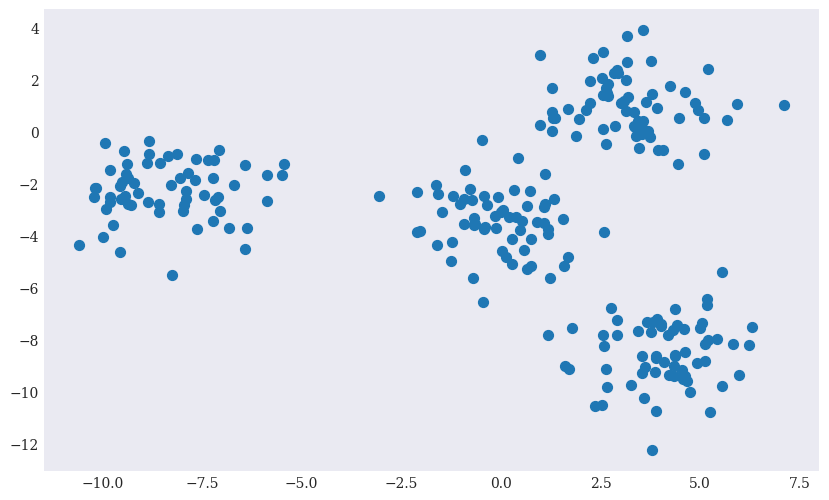

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=250, centers=4,
                              random_state=500, cluster_std=1.25)

plt.figure(figsize = (10,6));
plt.scatter(X[:,0], X[:,1], s = 50);

The goal of a clustering algorithm is therefore to recover the 4 clusters and properly classify each data point.

### 3.2. `K-means clustering`

#### A primer 

**`K-Means`** is an **unsupervised learning algorithm** used for **clustering** data.

**Goal**: partition data into **`k` distinct clusters** based on similarities.
- Each data point is assigned to the **nearest cluster**
    - Based on distance to the **centroid** $\mu_k$ (the center of the cluster $k$).
- The algorithm re-assigns clusters in order to minimize the **inertia** $J$
    - Sum of squared distances between points and their nearest cluster center.
    
$$
J = \sum_{k=1}^{K} \sum_{i \in C_k} \| x_i - \mu_k \|^2
$$

- **Algorithm**
    1. **Initialization**: 
       - Choose `K` initial centroids randomly or using smarter methods (e.g., k-means++).
    2. **Assignment**: 
       - Assign each data point to the nearest cluster centroid based on Euclidean distance.
    3. **Update**:
       - Recalculate the centroids by finding the mean of all points assigned to each cluster.
    4. **Repeat**:
       - Repeat the assignment and update steps until the centroids no longer change significantly (convergence).
    5. **Output**:
       - Final centroids and cluster assignments for each point.

**Visualisation**
<center><img src="Figures/kmeans.png" width = 900></img></center>

#### Workflow

##### Step 1 - Importing and instantiating the `KMeans` model class

The `scikit-learn` library contains a family class `cluster` with a subclass `KMeans`.

```python
    from sklearn.cluser import KMeans
    model = KMeans (param)
```
Parameters for the instantiation of a `KMeans` object:
- `n_clusters`: Number of clusters to form.
- `random_state`: Ensures reproducibility by fixing the random initialization of centroids.
- `max_iter`: The maximum number of iterations to run the algorithm.
- `init`: The method for initializing centroids (e.g., 'random', 'k-means++').
- `tol`: The tolerance to declare convergence.

##### Step 2 - Fitting the model to the data

Fitting the model to the data obtains with the method `.fit()` with the data as input.

```python
    model.fit(X)
```

This is where the optimization takes place.

##### Step 3 - Prediction

Predicting clusters obtains with the method `.predict()` with the data as input.

```python
    labels = model.predict(X)
```

The method associates a cluster label to each data point.

#### Application

In [3]:
from sklearn.cluster import KMeans
model = KMeans (n_clusters = 4, random_state = 0)
model.fit(X)
y_kmeans = model.predict(X)

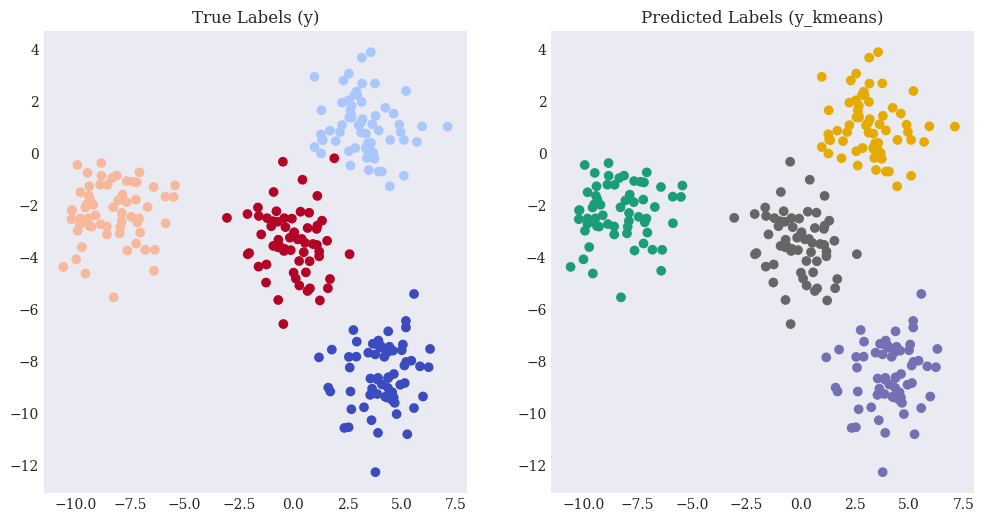

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# Plot true values (y)
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
axes[0].set_title("True Labels (y)")
# Plot predicted values (y_kmeans)
axes[1].scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='Dark2')
axes[1].set_title("Predicted Labels (y_kmeans)");


#### Step 4 - Parameter tuning (`k`)

Selecting the **optimal number** of `k` clusters is crucial for meaningful results.

Common techniques to determine `K`:

- **Elbow Method**: Plot the inertia for different values of `K` and look for an "elbow" where the decrease in inertia slows down.

- **Silhouette Score**: Measures how similar a point is to its cluster compared to other clusters.

## 4. Supervised Learning

In **supervised learning**, machine learning is achieved with **guidance** in the form of known results or **labelled** data. 

- With unsupervised learning, algorithms originate their own categorical labels of clusters identified.

- In supervised learning, labels are given. 

**Types of supervised learning algorithms**

| Algorithm                | Quick Description                          | Common Use Cases                      |
|--------------------------|--------------------------------------------|----------------------------------------|
| Linear Regression        | A model that fits a linear relationship    | Predicting continuous values          |
| Logistic Regression      | A model for binary/multiclass classification | Binary/multiclass classification    |
| Decision Trees           | Tree-like structure for decision making    | Easy-to-interpret models              |
| Support Vector Machines  | Finds the optimal boundary for classification | High-dimensional data              |
| Random Forest            | Ensemble of decision trees for better performance | Ensemble learning for robust predictions |
| Gradient Boosting        | Combines weak models to form a strong model | Improving weak learners               |
| Neural Networks          | Mimics the human brain with layers of nodes | Complex patterns and non-linear relationships |
| Ridge/Lasso Regression   | Linear models with regularization to prevent overfitting | Regularized linear models            |

In the following:

1. Generate labelled data

2. `Logistic regressions`
    - Apply the ML workflow
    - Performance evaluation

3. `Decision trees`
    - Apply the ML workflow
    - With sample split


### 4.1 Data

`scikit-learn` allows the creation of sample data sets for supervised ML problems.

The following uses the method `make_classification()` to create a sample data set suited to illustrating classification techniques.

**Data set creation with 2 classes and 20 features**

In [5]:
from sklearn.datasets import make_classification

n_samples = 10000
X, y = make_classification(n_samples=n_samples, n_features=20,
                                         n_informative=20, n_redundant=0,
                                         n_repeated=0, random_state=250)

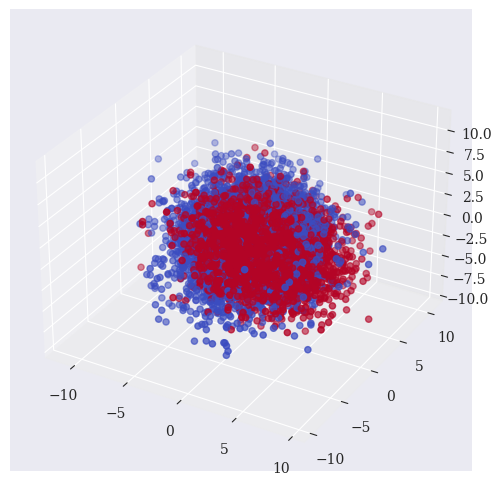

In [6]:
fig = plt.figure(figsize = (10,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='coolwarm', marker='o');

The goal of a classification algorithm is therefore to classify each 20-dimensional data point according to the binary value `y`.

### 4.2 `Logistic regression`

#### A primer

**`Logistic regressions`** model the probability of a particular class, using the **`logistic` function** (also known as the **`sigmoid` function**).

- **Linear Regression**: Predicts a continuous output (regression tasks).
- **Logistic Regression**: Predicts the probability of categorical outcomes (classification tasks).

The output is a probability value between 0 and 1, which is then used to classify data into different classes (e.g., true/false).

<center><img src="Figures/logistic.png" width = 800></img></center>

#### Workflow

##### Step 1 - Importing and instantiating the `Logistic` model class

The `scikit-learn` library contains a family class `linear_model` with a subclass `LogisticRegression`.

```python
    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression(param)
```

##### Step 2 - Fitting the model to the data

Fitting the model to the data obtains with the method `.fit()` with the data **and label** as input.

```python
    model.fit(X,y)
```

This is where the optimization takes place.

##### Step 3 - Prediction

Predicting labels obtains with the method `.predict` with the data as input.

```python
    pred = model.predict(X)
```

The method associates a prediction output to each data point.

#### Application

In [7]:
from sklearn.linear_model import LogisticRegression
# model = LogisticRegression(C = 1, solver = 'lbfgs')
model = LogisticRegression()

model.fit(X,y)

pred = model.predict(X)

#### Step 4 - Evaluation

In [8]:
Xc = X[y == pred]
Xf = X[y != pred]

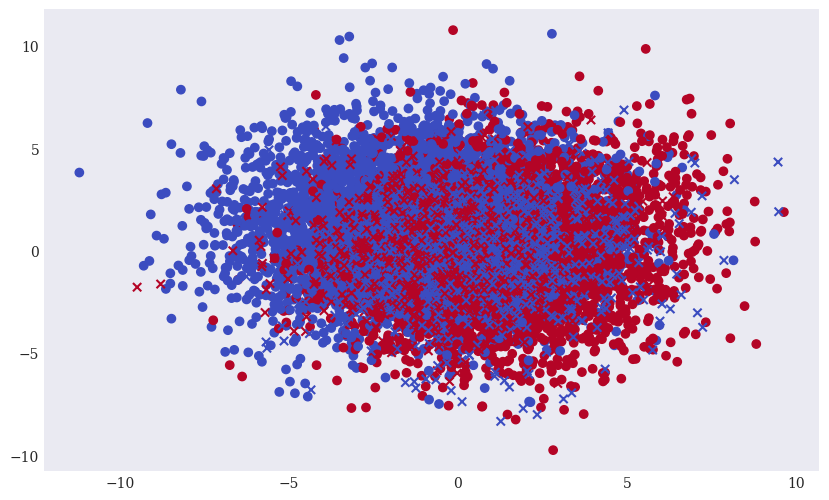

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(x=Xc[:, 0], y=Xc[:, 1], c=y[y == pred],
                         marker='o', cmap='coolwarm')
plt.scatter(x=Xf[:, 0], y=Xf[:, 1], c=y[y != pred],
                         marker='x', cmap='coolwarm');

Given the prediction of the model, there are several ways to **assess the performance** of the model. 

**Confusion matrix**

| Actual \ Predicted | Positive Prediction | Negative Prediction |
|---------------------|----------------------------|------------------------------|
| Positive   | True Positive (TP)         | False Negative (FN)          |
| Negative   | False Positive (FP)        | True Negative (TN)           |



**Performance metrics**
- **Accuracy**: The ratio of correct predictions to total predictions.
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$
- **Precision**: The ratio of true positives to predicted positives.
$$
\text{Precision} = \frac{TP}{TP + FP}
$$
- **Recall**: The ratio of true positives to actual positives.
$$
\text{Recall} = \frac{TP}{TP + FN}
$$


- **F1 Score**: The harmonic mean of precision and recall, providing a single measure that balances both.

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y, pred)
precision = precision_score(y, pred)  
recall = recall_score(y, pred)  
f1 = f1_score(y, pred)              

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.85
Precision: 0.84
Recall: 0.88
F1 Score: 0.86


### 4.3 `Decision trees`


#### A primer

**`Decision trees`** model predictions as a tree-like structure, where:

- **Internal nodes** represent a feature or attribute on which the data is split.
- **Branches** represent the outcome of the decision based on that feature.  
- **Leaf nodes** represent the final output or class label.

Decision trees are easy to interpret and can handle both numerical and categorical data.

**Example of a <u>trained</u> decision tree** (depth = 3)

                           (Root) Credit Score >= 650?
                          /                            \
                    Yes                                  No
              Income >= 3000?                           Default: Deny
             /               \
          Yes                No
       Loan Amount <= 20000?    Default: Deny
        /         \
      Yes         No
    No-Default: Approve      Default: Deny

**The issue of overfitting**

With enough **depth**, a decision tree can fit any data. 

&rarr; Need to **split** data before engaging in training.

#### Workflow

##### Step 1 - Train-test split data

**Recall**: data needs to be split in 2 parts:
  1. **Training Set**: Used to train the model (70-80% of the data)
  3. **Test Set**: Used to evaluate the model's performance (20-30% of the data)


The `scikit-learn` library contains a family class `model_selection` with a subclass `train_test_split`.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
```

Parameters in `train_test_split`

- **`test_size`**: Specifies the proportion of the dataset to include in the test split. For example, `test_size=0.2` means 20% of the data will be used as the test set.
- **`random_state`**: Controls the shuffling of data before splitting. A fixed `random_state` ensures reproducibility, meaning the same split will be produced each time.
- **`shuffle`**: By default, the data is shuffled before splitting to ensure a random distribution between training and test sets.

##### Step 2 - Importing and instantiating the `DecisionTree` model class

The `scikit-learn` library contains a family class `tree` with a subclass `DecisionTreeClassifier`.

```python
    from sklearn.tree import DecisionTreeClassifier
    model = DecisionTreeClassifier(param)
```
With parameters:
- `max_depth`: The maximum depth of the tree. Limiting depth prevents overfitting.
- `min_samples_split`: The minimum number of samples required to split an internal node.
- `min_samples_leaf`: The minimum number of samples required to be in a leaf node.
- `criterion`: The function used to measure the quality of a split (e.g., `gini` for Gini impurity or `entropy` for information gain in classification, `mse` for regression).
- `max_features`: The number of features to consider when looking for the best split.

##### Step 3 - Fitting the model to data

Fitting the model to the data obtains with the method `.fit()` with **the training data and label as input**.
```python
    model.fit(X_train,y_train)
```
This is where the optimization takes place.

##### Step 4 - Prediction

Predicting clusters obtains with the method `.predict()` with the **test data** as input.
```python
    y_pred = model.predict_proba(X_test)
```
The method associates an output prediction to each data point in the test set.

#### Application

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Output the sizes of the training and test sets
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (8000, 20)
Test set size: (2000, 20)


**Starting with `depth = 1`**

In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=1)

In [13]:
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=1)

In [14]:
y_pred = model.predict(X_test)

#### Step 5 - Evaluation

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.65
Precision: 0.65
Recall: 0.69
F1 Score: 0.67


In [16]:
Xc = X_test[y_test == y_pred]
Xf = X_test[y_test != y_pred]

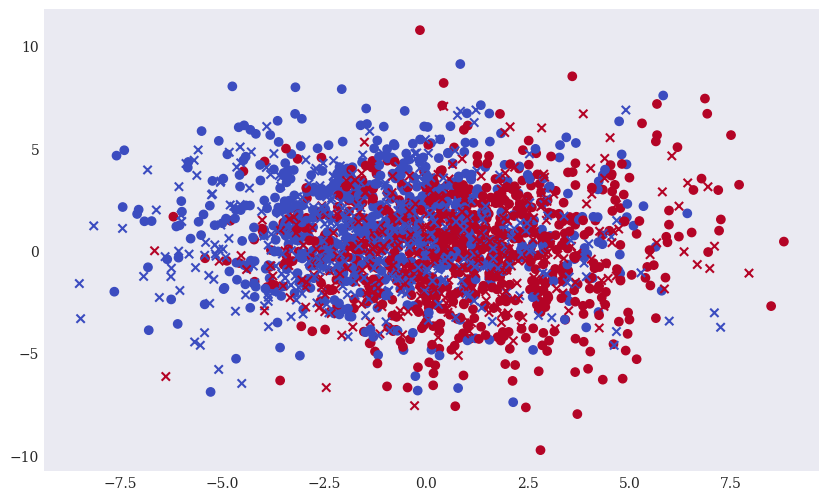

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(x=Xc[:, 0], y=Xc[:, 1], c=y_test[y_test == y_pred],
                         marker='o', cmap='coolwarm')
plt.scatter(x=Xf[:, 0], y=Xf[:, 1], c=y_test[y_test != y_pred],
                         marker='x', cmap='coolwarm');

**Increasing maximum depth**

*with training*

In [18]:
print('{:>8s} | {:10s} | {:10s} | {:10s} | {:10s}'.format('depth', 'accuracy', 'precision', 'recall', 'f1')) 
print(60 * '-')
for depth in range(1, 20):
    model = DecisionTreeClassifier(max_depth=depth) 
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test)) 
    # accuracy = accuracy_score(y_test,y_pred)
    prec = precision_score(y_test,model.predict(X_test))
    rec = recall_score(y_test,model.predict(X_test))
    f1 = f1_score(y_test,model.predict(X_test))
    print('{:8d} | {:10.2f} | {:10.2f} | {:10.2f} | {:10.2f}'.format(depth, acc, prec, rec, f1))

   depth | accuracy   | precision  | recall     | f1        
------------------------------------------------------------
       1 |       0.65 |       0.65 |       0.69 |       0.67
       2 |       0.73 |       0.72 |       0.78 |       0.75
       3 |       0.75 |       0.74 |       0.80 |       0.77
       4 |       0.78 |       0.81 |       0.73 |       0.77
       5 |       0.81 |       0.83 |       0.80 |       0.81
       6 |       0.84 |       0.85 |       0.82 |       0.84
       7 |       0.84 |       0.86 |       0.81 |       0.84
       8 |       0.85 |       0.85 |       0.86 |       0.85
       9 |       0.85 |       0.85 |       0.86 |       0.86
      10 |       0.85 |       0.86 |       0.85 |       0.85
      11 |       0.85 |       0.86 |       0.84 |       0.85
      12 |       0.86 |       0.87 |       0.85 |       0.86
      13 |       0.85 |       0.86 |       0.84 |       0.85
      14 |       0.85 |       0.86 |       0.84 |       0.85
      15 |       0.85 | 

*with overfitting*

In [19]:
print('{:>8s} | {:10s} | {:10s} | {:10s} | {:10s}'.format('depth', 'accuracy', 'precision', 'recall', 'f1')) 
print(60 * '-')
for depth in range(1, 20):
    model = DecisionTreeClassifier(max_depth=depth) 
    model.fit(X, y)
    acc = accuracy_score(y, model.predict(X)) 
    # accuracy = accuracy_score(y_test,y_pred)
    prec = precision_score(y,model.predict(X))
    rec = recall_score(y,model.predict(X))
    f1 = f1_score(y,model.predict(X))
    print('{:8d} | {:10.2f} | {:10.2f} | {:10.2f} | {:10.2f}'.format(depth, acc, prec, rec, f1))

   depth | accuracy   | precision  | recall     | f1        
------------------------------------------------------------
       1 |       0.67 |       0.66 |       0.71 |       0.68
       2 |       0.73 |       0.71 |       0.78 |       0.74
       3 |       0.76 |       0.73 |       0.80 |       0.77
       4 |       0.79 |       0.80 |       0.76 |       0.78
       5 |       0.82 |       0.84 |       0.81 |       0.82
       6 |       0.86 |       0.86 |       0.85 |       0.86
       7 |       0.88 |       0.90 |       0.86 |       0.88
       8 |       0.91 |       0.90 |       0.92 |       0.91
       9 |       0.93 |       0.93 |       0.93 |       0.93
      10 |       0.94 |       0.94 |       0.95 |       0.94
      11 |       0.96 |       0.96 |       0.96 |       0.96
      12 |       0.97 |       0.97 |       0.97 |       0.97
      13 |       0.98 |       0.98 |       0.98 |       0.98
      14 |       0.99 |       0.99 |       0.99 |       0.99
      15 |       0.99 | 

## Some applications in Finance

### Credit card fraud

>It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase.

In this example, we’ll use a **decision tree classifier** to detect fraudulent credit card transactions. 

The target variable is `Class`, where `0` indicates non-fraudulent transactions, and `1` indicates fraudulent transactions.

#### Data

- The dataset contains transactions made by credit cards in September 2013 by European cardholders. 
- This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. 
- The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.
- Due to confidentiality issues, it contains only numerical input variables which are the result of a PCA transformation. 
- The only features which have not been transformed with PCA are 'Time' and 'Amount'. 
    - Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. 
    - The feature 'Amount' is the transaction Amount.
- Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

#### Step 1: Import Required Libraries

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

#### Step 2: Import and prepare the Data

In [21]:
df = pd.read_csv('Data/13/creditcard.csv')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [23]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Decompose input and label data**

In [24]:
X = df.drop(columns=['Class'])
y = df['Class']

#### Step 3: Split the Data

To evaluate the model, split the data into training and testing sets.

In [25]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### Step 4: Train the Decision Tree Model

Initialize and train the decision tree classifier.

In [26]:
# Initialize the decision tree classifier
clf = DecisionTreeClassifier(max_depth=4, random_state=42)

# Train the classifier
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

#### Step 5: Make Predictions

Use the trained model to predict fraud on the test set.

In [27]:
# Predict on the test set
y_pred = clf.predict(X_test)


#### Step 6: Evaluate the Model

Assess the model’s performance using accuracy, confusion matrix, and classification report.

In [28]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.999420666409185
Confusion Matrix:
[[56849    15]
 [   18    80]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.82      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



#### Step 7: Visualize the Decision Tree

Plotting the tree helps in understanding the decisions being made by the model.

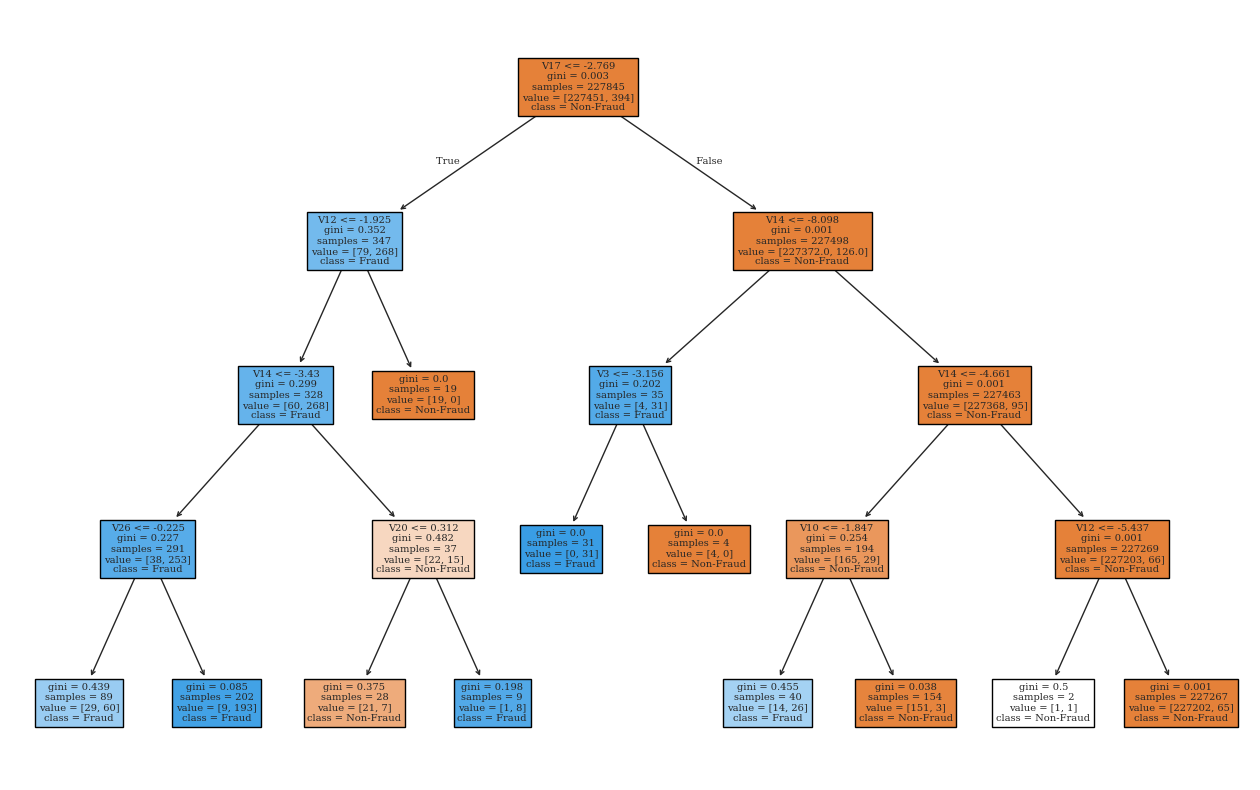

In [29]:
plt.figure(figsize=(16, 10))
plot_tree(clf, feature_names=X.columns, class_names=["Non-Fraud", "Fraud"], filled=True)
plt.show()

### Anomaly detection

<u> Exercise </u>: Code interpreation with the following information

- Data set: `Binance_Data.csv`

In [30]:
file_path = 'Data/13/Binance_Data.csv'
df = pd.read_csv(file_path)

- Machine learning method: K-Means and Scaler

In [34]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

> `StandardScaler` is a preprocessing tool from the `sklearn.preprocessing` module in the `Scikit-Learn` library. It’s used to standardize or normalize data, which means scaling the features so that they have a mean of zero and a standard deviation of one. This is commonly done to improve the performance of machine learning models, especially those sensitive to the scale of input data, like K-Means clustering, logistic regression, and neural networks.


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     1000 non-null   object 
 1   datetime      1000 non-null   object 
 2   open          1000 non-null   float64
 3   high          1000 non-null   float64
 4   low           1000 non-null   float64
 5   close         1000 non-null   float64
 6   volume        1000 non-null   float64
 7   year          1000 non-null   int64  
 8   month         1000 non-null   int64  
 9   day           1000 non-null   int64  
 10  day_of_week   1000 non-null   int64  
 11  hour          1000 non-null   int64  
 12  close_lag_1   1000 non-null   float64
 13  close_lag_2   1000 non-null   float64
 14  close_lag_3   1000 non-null   float64
 15  volume_lag_1  1000 non-null   float64
 16  volume_lag_2  1000 non-null   float64
 17  volume_lag_3  1000 non-null   float64
dtypes: float64(11), int64(5), obj

In [32]:
df.describe()

,open,high,low,close,volume,year,month,day,day_of_week,hour,close_lag_1,close_lag_2,close_lag_3,volume_lag_1,volume_lag_2,volume_lag_3
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.381544,0.361754,0.392182,0.382187,0.016678,2024.0,7.0,9.516000,1.516000,11.388000,0.381549,0.380906,0.380243,0.016677,0.016671,0.016657
std,0.290476,0.279328,0.280658,0.290416,0.038731,0.0,0.0,0.499994,0.499994,8.186848,0.290464,0.290506,0.290523,0.038731,0.038732,0.038734
min,0.000000,0.000000,0.000000,0.000000,0.000000,2024.0,7.0,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.185062,0.174213,0.202424,0.185124,0.005342,2024.0,7.0,9.000000,1.000000,4.000000,0.185057,0.184746,0.184315,0.005317,0.005305,0.005291
50%,0.261445,0.244322,0.278768,0.261587,0.009631,2024.0,7.0,10.000000,2.000000,8.000000,0.261443,0.261291,0.261169,0.009631,0.009585,0.009548
75%,0.692634,0.664926,0.686385,0.692631,0.017063,2024.0,7.0,10.000000,2.000000,19.000000,0.692631,0.692631,0.692068,0.017063,0.017063,0.016997
max,1.000000,1.000000,1.000000,1.000000,1.000000,2024.0,7.0,10.000000,2.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Interpret the following code**

In [35]:
df['Close_Price_Change'] = df['close'].pct_change().fillna(0) * 100
df['Volatility'] = df['high'] - df['low']  

data_for_clustering = df[['volume', 'Close_Price_Change', 'Volatility']].replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

kmeans = KMeans(n_clusters=5, random_state=0)
data_for_clustering['Cluster'] = kmeans.fit_predict(data_scaled)

data_for_clustering['Distance_to_Center'] = np.linalg.norm(data_scaled - kmeans.cluster_centers_[data_for_clustering['Cluster']], axis=1)

threshold = data_for_clustering['Distance_to_Center'].quantile(0.95)
data_for_clustering['Anomaly'] = data_for_clustering['Distance_to_Center'] > threshold

data_for_clustering.head(10)

,volume,Close_Price_Change,Volatility,Cluster,Distance_to_Center,Anomaly
0,0.005119,0.000000,-0.035679,1,0.161866,False
1,0.004273,-30.841352,-0.035655,0,1.794493,True
2,0.072361,90.545844,-0.014283,4,3.049216,True
3,0.018940,-4.343756,-0.036998,1,0.420190,False
4,0.024734,12.321394,-0.028574,1,0.912231,False
5,0.012141,11.806221,-0.040566,1,0.685271,False
6,0.042371,13.567643,-0.010533,0,1.539356,False
7,0.020318,-40.520140,-0.017741,0,1.910051,True
8,0.018252,-17.247347,-0.031735,0,1.018215,False
9,0.014233,4.781821,-0.040405,1,0.305875,False
